# LLM Agent Evaluation: simple evals

Imagine your marketing team is preparing for a new product launch and needs to publish updates on social media every day. Writing short, catchy tweets takes time, so you decide to use an LLM to generate first drafts automatically. However, not every model output is ready to post. Some tweets are too long, some include emojis that don’t match the brand style, and others forget to add important hashtags.

To make this workflow reliable, you start with a few simple automated checks: the tweet must stay within the character limit, avoid emojis, and include at least one hashtag.

In this example, we will build and test these lightweight rules before moving on to more advanced evaluation techniques.

In [1]:
# Import libraries
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pd.set_option('display.max_colwidth', None)

## 1. Synthetic Dataset

We'll create a static dataset with topics and tweets. Some tweets will pass validation, some will fail.

In [3]:
# Static synthetic dataset

synthetic_data = [
    #Product launch
    ("Product launch", "Introducing InsightPulse: real-time monitoring for your ML models in production. Catch drift early, explain issues faster, and keep stakeholders confident. #MLOps #AI"),  # pass
    ("Product launch", "We just launched our evaluation templates for LLM apps. Start with simple checks and grow from there. 🚀 #LLM #Evals"),  # fail: emojis
    ("Product launch", "Today we shipped major improvements: faster eval runs, clearer reports, and smarter filters for comparing prompts across scenarios and releases. If you build LLM apps, iteration speed matters as much as accuracy. More updates soon. #ProductUpdate #LLM #Evals #AI"),  
    ("Product launch", "New build is live. If you spot anything weird, send us a note."),  # fail: missing hashtags
    ("Product launch", "Big news: we are rolling out a workflow that generates posts, checks them, and retries on failure. The key is explaining why something failed and how to fix it, so teams can ship with confidence. 🎯🔥 #Automation #LLM #Product #Quality #Testing"),  # fail: emojis 

    #Webinar announcement
    ("Webinar announcement", "Join our live webinar on practical LLM evaluation: test for length, tone, and policy constraints with simple, repeatable checks. Save your seat today. #LLM #Evaluation"),  # pass
    ("Webinar announcement", "Join our live webinar tomorrow at 10:00 UTC. We will walk through a simple tweet-generator case and show how to validate outputs with lightweight checks."),  # fail: missing hashtags
    ("Webinar announcement", "Seats are filling up fast — last call to register. 🎉 #Webinar #LLM"),  # fail: emojis
    ("Webinar announcement", "A reminder: LLM outputs are not 'done' when the model returns text. They are done when they pass constraints, match your brand voice, and stay consistent across edge cases. That is why we treat prompts like code, add tests, and review failures like bugs. #LLM #Quality #Testing #AI"),  # fail: too long
    ("Webinar announcement", "Tomorrow’s session covers generation, validation, retries, and reporting for LLM workflows. We will share a checklist and a reference implementation you can adapt. 😊 #LLM #Evals #Webinar"),  # fail: emojis (and maybe length depending)

    #Hiring
    ("Hiring", "We are hiring a Product Designer who loves turning complex systems into simple experiences. Remote-friendly, fast-paced team, meaningful work. #Hiring #Design"),  # pass
    ("Hiring", "We are hiring a Backend Engineer to help scale our evaluation pipelines. Experience with Python and distributed systems is a plus. #Hiring #Engineering"),  # pass
    ("Hiring", "We are hiring across roles this quarter. If you enjoy building tools that help teams ship reliable AI, we would love to hear from you. Apply now."),  # fail: missing hashtags
    ("Hiring", "We are hiring and we move fast. Come build with us. 🚀 #Hiring"),  # fail: emojis
    ("Hiring", "We are growing the team to support more users and more evaluation workloads: faster scheduling, clearer results, and better debugging. If you want to build infrastructure that makes AI products safer to ship, apply today. #Hiring #AI #Infrastructure #Engineering #Careers"),  

    #Feature update
    ("Feature update", "New in our dashboard: compare prompt variants side by side and track quality metrics over time. Fewer regressions, faster iteration. #PromptEngineering #ProductUpdate"),  # pass
    ("Feature update", "Feature update: you can now group evaluation results by scenario, filter by failure type, and export summaries for reviews. #ProductUpdate #Evals"),  # pass
    ("Feature update", "New: side-by-side comparisons for prompts and models, plus saved filters for recurring checks. 🎯 #ProductUpdate #LLM"),  # fail: emojis
    ("Feature update", "We improved the evaluation pipeline to make failures actionable. Instead of a single score, you can see which constraints broke and how often, so teams can iterate with confidence."),  # fail: missing hashtags
    ("Feature update", "Still thinking about how often teams ship LLM features without guardrails. This release adds validation, retries, and clearer failure reports so you can debug issues quickly and keep output consistent across edge cases and languages. 😊🚀 #AI #LLM #Evals #Quality #Testing"),  # fail: emojis 

    #Conference promo
    ("Conference promo", "See you at PyData London. We will share a hands-on demo of evaluating multi-step AI workflows with lightweight tests and clear reports. #PyData #AI"),  # pass
    ("Conference promo", "Catch our talk next week: a practical demo of LLM workflow evaluation, from simple constraints to actionable failure reports. #Conference #LLM"),  # pass
    ("Conference promo", "We will be at the conference all week — come say hi at our booth."),  # fail: missing hashtags
    ("Conference promo", "On our way to the conference. Excited to share demos and meet teams building reliable AI. 🎉 #AI #Conference"),  # fail: emojis
    ("Conference promo", "At the conference we saw many bold demos, but not enough proof. Our takeaway: if an LLM is in your product, you need evals that are cheap to run and easy to understand, not just a fancy score. We will share our checklist soon. 🚀 #AI #LLM #Evals #Quality #Testing"),  # fail: emojis 
]

# Convert to pandas DataFrame
df = pd.DataFrame(synthetic_data, columns=['topic', 'tweet'])

print(f"Total tweets in the dataset: {len(df)}")
df.head()

Total tweets in the dataset: 25


,topic,tweet
0,Product launch,"Introducing InsightPulse: real-time monitoring for your ML models in production. Catch drift early, explain issues faster, and keep stakeholders confident. #MLOps #AI"
1,Product launch,We just launched our evaluation templates for LLM apps. Start with simple checks and grow from there. 🚀 #LLM #Evals
2,Product launch,"Today we shipped major improvements: faster eval runs, clearer reports, and smarter filters for comparing prompts across scenarios and releases. If you build LLM apps, iteration speed matters as much as accuracy. More updates soon. #ProductUpdate #LLM #Evals #AI"
3,Product launch,"New build is live. If you spot anything weird, send us a note."
4,Product launch,"Big news: we are rolling out a workflow that generates posts, checks them, and retries on failure. The key is explaining why something failed and how to fix it, so teams can ship with confidence. 🎯🔥 #Automation #LLM #Product #Quality #Testing"


## 2. Validation Checks

We'll implement validation checks using raw Python and regular expressions.

In [4]:
# Set tweet lenth limit and compile regex patterns once for efficiency
len_limit = 280

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"  # dingbats
    "\U000024C2-\U0001F251"  # enclosed characters
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA00-\U0001FA6F"  # chess symbols
    "\U0001FA70-\U0001FAFF"  # symbols and pictographs extended-A
    "]+"
)

hashtag_pattern = re.compile(r"#\w+")

In [5]:
# Apply validation to all tweets in the dataset
df["length_ok"] = df["tweet"].apply(lambda x: len(x) <= len_limit)
df["no_emoji"] = df["tweet"].apply(lambda x: not bool(emoji_pattern.search(x)))
df["has_hashtag"] = df["tweet"].apply(lambda x: bool(hashtag_pattern.search(x)))

df.head()

,topic,tweet,length_ok,no_emoji,has_hashtag
0,Product launch,"Introducing InsightPulse: real-time monitoring for your ML models in production. Catch drift early, explain issues faster, and keep stakeholders confident. #MLOps #AI",True,True,True
1,Product launch,We just launched our evaluation templates for LLM apps. Start with simple checks and grow from there. 🚀 #LLM #Evals,True,False,True
2,Product launch,"Today we shipped major improvements: faster eval runs, clearer reports, and smarter filters for comparing prompts across scenarios and releases. If you build LLM apps, iteration speed matters as much as accuracy. More updates soon. #ProductUpdate #LLM #Evals #AI",True,True,True
3,Product launch,"New build is live. If you spot anything weird, send us a note.",True,True,False
4,Product launch,"Big news: we are rolling out a workflow that generates posts, checks them, and retries on failure. The key is explaining why something failed and how to fix it, so teams can ship with confidence. 🎯🔥 #Automation #LLM #Product #Quality #Testing",True,False,True


In [6]:
# Add tests summary across tweets
df["passed_all"] = df["length_ok"] & df["no_emoji"] & df["has_hashtag"]
df["score"] = df[["length_ok", "no_emoji", "has_hashtag"]].sum(axis=1)

df.head()

,topic,tweet,length_ok,no_emoji,has_hashtag,passed_all,score
0,Product launch,"Introducing InsightPulse: real-time monitoring for your ML models in production. Catch drift early, explain issues faster, and keep stakeholders confident. #MLOps #AI",True,True,True,True,3
1,Product launch,We just launched our evaluation templates for LLM apps. Start with simple checks and grow from there. 🚀 #LLM #Evals,True,False,True,False,2
2,Product launch,"Today we shipped major improvements: faster eval runs, clearer reports, and smarter filters for comparing prompts across scenarios and releases. If you build LLM apps, iteration speed matters as much as accuracy. More updates soon. #ProductUpdate #LLM #Evals #AI",True,True,True,True,3
3,Product launch,"New build is live. If you spot anything weird, send us a note.",True,True,False,False,2
4,Product launch,"Big news: we are rolling out a workflow that generates posts, checks them, and retries on failure. The key is explaining why something failed and how to fix it, so teams can ship with confidence. 🎯🔥 #Automation #LLM #Product #Quality #Testing",True,False,True,False,2


## 3. Statistics Over Evaluated Metrics

Calculate and display statistics for each validation metric

In [7]:
#Checks summary
report = df.groupby("topic").agg(
    total_tweets=("tweet", "count"),
    passed=("passed_all", "sum"),
    failed=("passed_all", lambda x: (~x).sum()),
    pass_rate=("passed_all", "mean"),
)

report["pass_rate"] = (report["pass_rate"] * 100).round(1)

report

,total_tweets,passed,failed,pass_rate
topic,,,,
Conference promo,5,2,3,40.0
Feature update,5,2,3,40.0
Hiring,5,3,2,60.0
Product launch,5,2,3,40.0
Webinar announcement,5,1,4,20.0


In [8]:
#Checks detailed summary
rows = []
test_cols = ["length_ok", "no_emoji", "has_hashtag"]

for topic, group in df.groupby("topic"):
    for test in test_cols:
        passed = group[test].sum()
        total = len(group)
        failed = total - passed

        rows.append({
            "topic": topic,
            "test": test,
            "passed": passed,
            "failed": failed,
            "pass_rate_%": round(passed / total * 100, 1)
        })

detailed_report = pd.DataFrame(rows)

detailed_report

,topic,test,passed,failed,pass_rate_%
0,Conference promo,length_ok,5,0,100.0
1,Conference promo,no_emoji,3,2,60.0
2,Conference promo,has_hashtag,4,1,80.0
3,Feature update,length_ok,5,0,100.0
4,Feature update,no_emoji,3,2,60.0
5,Feature update,has_hashtag,4,1,80.0
6,Hiring,length_ok,5,0,100.0
7,Hiring,no_emoji,4,1,80.0
8,Hiring,has_hashtag,4,1,80.0
9,Product launch,length_ok,5,0,100.0


In [9]:
pivot_report = detailed_report.pivot(
    index="topic",
    columns="test",
    values="pass_rate_%"
)

pivot_report

test,has_hashtag,length_ok,no_emoji
topic,,,
Conference promo,80.0,100.0,60.0
Feature update,80.0,100.0,60.0
Hiring,80.0,100.0,80.0
Product launch,80.0,100.0,60.0
Webinar announcement,80.0,80.0,60.0


## 4. Visualisation

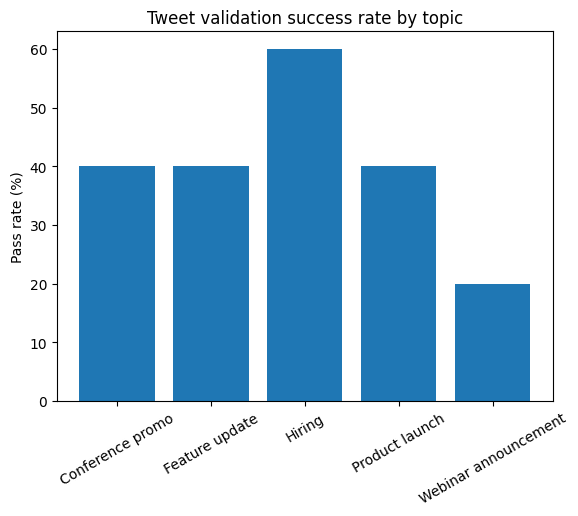

In [10]:
plt.figure()

plt.bar(report.index, report["pass_rate"])

plt.ylabel("Pass rate (%)")
plt.title("Tweet validation success rate by topic")
plt.xticks(rotation=30)

plt.show()

<Figure size 640x480 with 0 Axes>

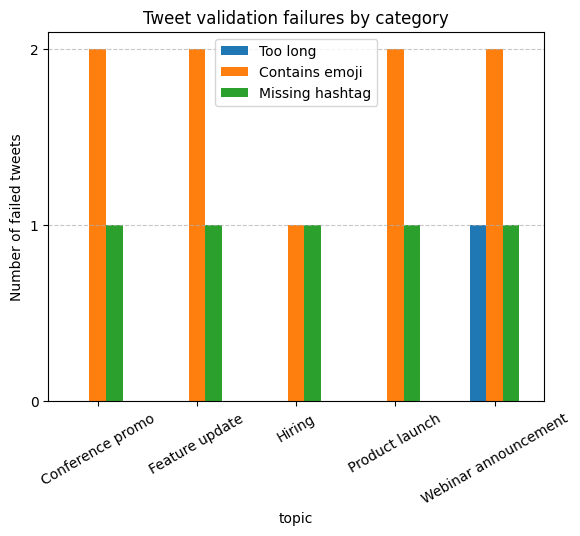

In [11]:
# Count failures per topic
failures = df.groupby("topic")[test_cols].apply(lambda x: (~x).sum())

failures = failures.rename(columns={
    "length_ok": "Too long",
    "no_emoji": "Contains emoji",
    "has_hashtag": "Missing hashtag"
})

plt.figure()

failures.plot(kind="bar", stacked=False)

plt.ylabel("Number of failed tweets")
plt.title("Tweet validation failures by category")
plt.xticks(rotation=30)
plt.yticks(np.arange(0, failures.values.max() + 1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()